In [6]:
import imdlib as imd
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np

# 1. Define the path and years we downloaded
data_dir = '../data/raw/rainfall'
start_yr = 2020
end_yr = 2025

print("Loading raw IMD binary files into memory...")
# 2. Open the .grd files using imdlib
rain_data = imd.open_data('rain', start_yr, end_yr, 'yearwise', data_dir)

# 3. Convert directly to an xarray Dataset for easy exploration
ds_rain = rain_data.get_xarray()
print(ds_rain)

Loading raw IMD binary files into memory...
<xarray.Dataset> Size: 305MB
Dimensions:  (time: 2192, lat: 129, lon: 135)
Coordinates:
  * time     (time) datetime64[ns] 18kB 2020-01-01 2020-01-02 ... 2025-12-31
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
Data variables:
    rain     (time, lat, lon) float64 305MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-06-28 09:36:48.795094 Python
    references:   
    comment:      
    crs:          epsg:4326


In [1]:
import imdlib as imd
import xarray as xr


data_dir = '../data/raw/rainfall'
start_yr = 2020
end_yr = 2025

print("Loading binary files into memory...")

rain_data = imd.open_data('rain', start_yr, end_yr, 'yearwise', data_dir)


ds_rain = rain_data.get_xarray()

print("--- Xarray Object Structure ---")
ds_rain

Loading binary files into memory...
--- Xarray Object Structure ---


<xarray.Dataset> Size: 305MB
Dimensions:  (time: 2192, lat: 129, lon: 135)
Coordinates:
  * time     (time) datetime64[ns] 18kB 2020-01-01 2020-01-02 ... 2025-12-31
  * lat      (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * lon      (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
Data variables:
    rain     (time, lat, lon) float64 305MB -999.0 -999.0 ... -999.0 -999.0
Attributes:
    Conventions:  CF-1.7
    title:        IMD gridded data
    source:       https://imdpune.gov.in/
    history:      2026-06-28 09:34:15.497547 Python
    references:   
    comment:      
    crs:          epsg:4326

In [2]:
import pandas as pd

print("Converting only 2024...")

df = ds_rain.sel(time="2024").to_dataframe().reset_index()

print(df.head())
print(df.shape)

Converting only 2024...
        time  lat    lon   rain
0 2024-01-01  6.5  66.50 -999.0
1 2024-01-01  6.5  66.75 -999.0
2 2024-01-01  6.5  67.00 -999.0
3 2024-01-01  6.5  67.25 -999.0
4 2024-01-01  6.5  67.50 -999.0
(6373890, 4)


In [3]:
df = df.rename(columns={
    "lat":"latitude",
    "lon":"longitude",
    "rain":"rainfall_mm"
})

df = df.dropna()

df = df[df["rainfall_mm"] >= 0]

print(df.head())

           time  latitude  longitude  rainfall_mm
987  2024-01-01      8.25      77.00          0.0
988  2024-01-01      8.25      77.25          0.0
989  2024-01-01      8.25      77.50          0.0
990  2024-01-01      8.25      77.75          0.0
1121 2024-01-01      8.50      76.75          0.0


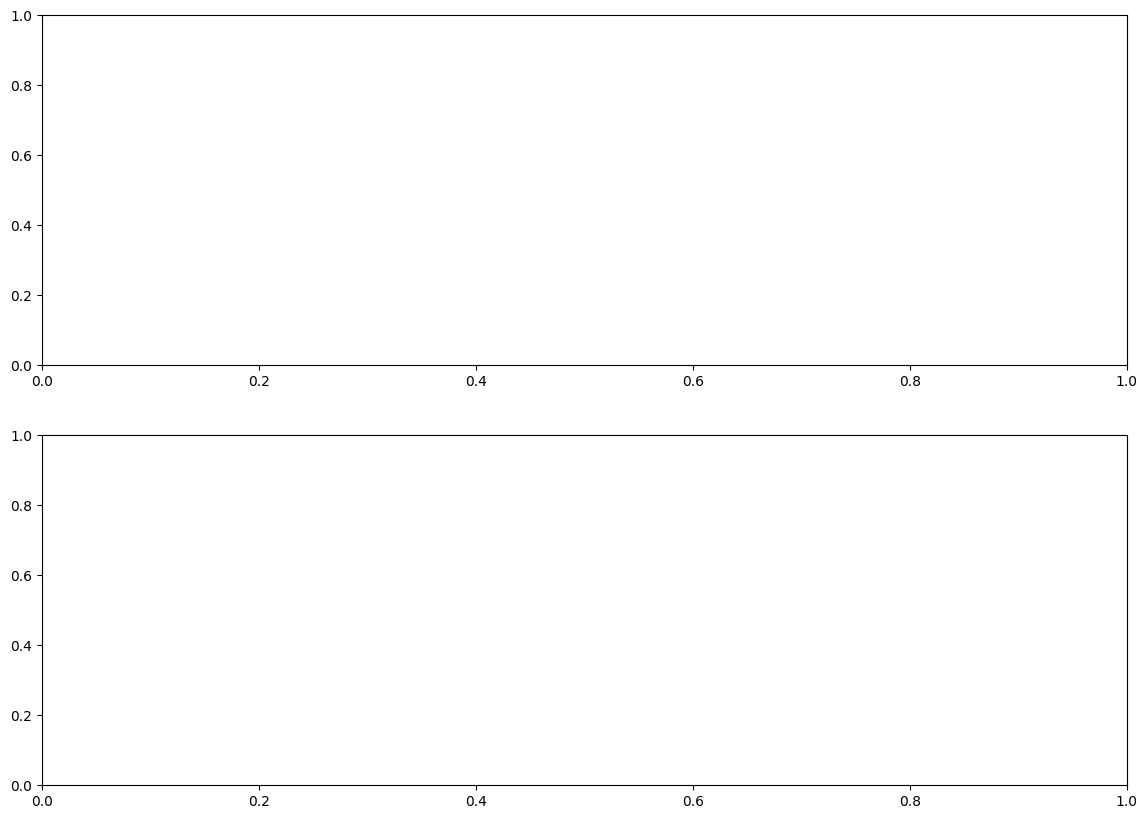

In [10]:
import matplotlib.pyplot as plt

ds_rain['rain'] = ds_rain['rain'].where(ds_rain['rain'] != -999.0)


fig, axes = plt.subplots(2, 1, figsize=(14, 10))

In [4]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = 0
df["dayofyear"] = df["time"].dt.dayofyear

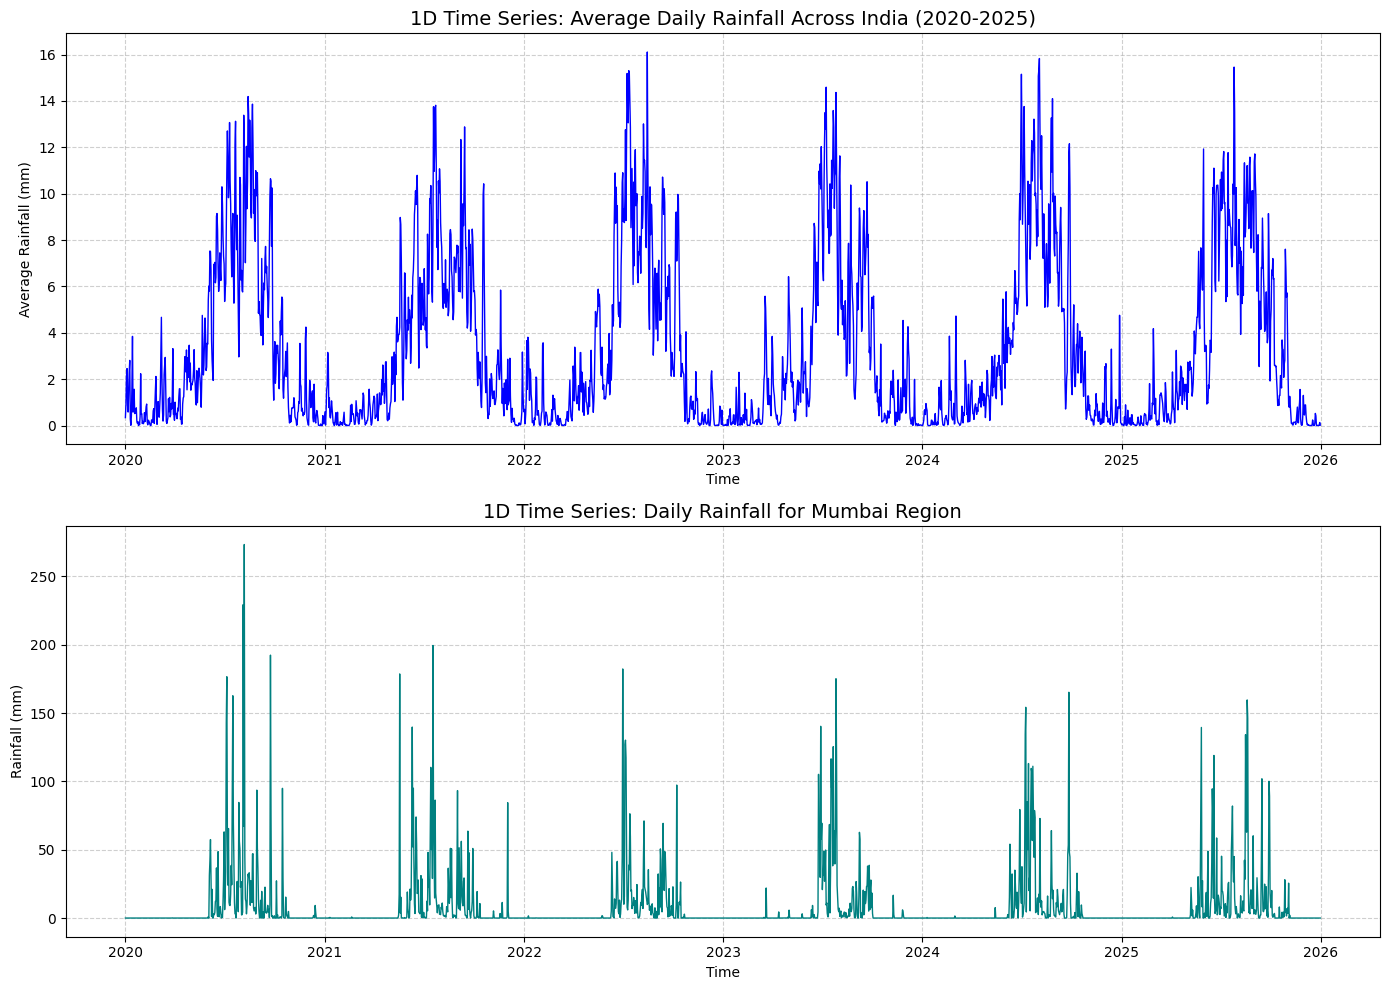

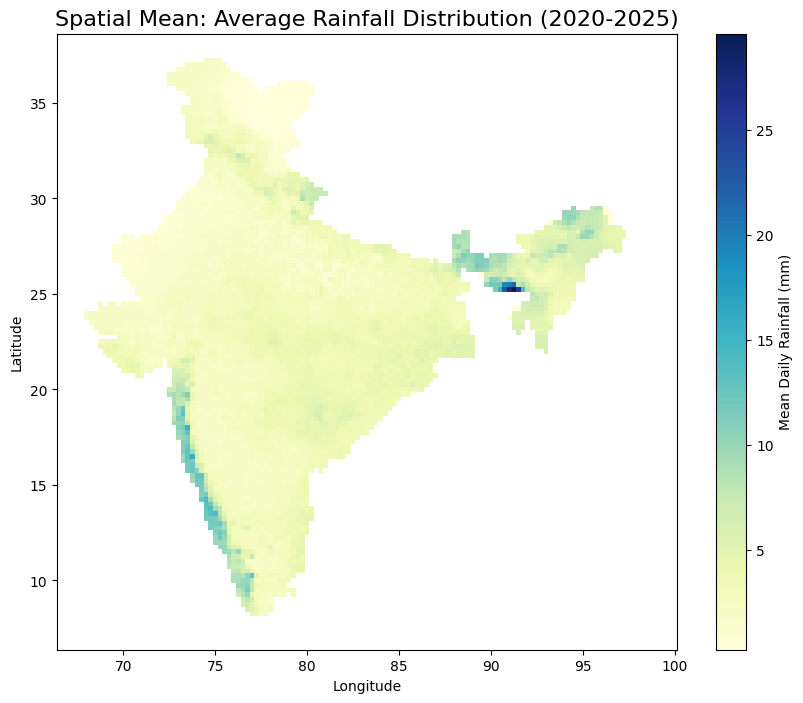

In [11]:
import matplotlib.pyplot as plt


ds_rain['rain'] = ds_rain['rain'].where(ds_rain['rain'] != -999.0)


fig, axes = plt.subplots(2, 1, figsize=(14, 10))


india_mean_timeseries = ds_rain['rain'].mean(dim=['lat', 'lon'])
india_mean_timeseries.plot(ax=axes[0], color='blue', linewidth=1)
axes[0].set_title('1D Time Series: Average Daily Rainfall Across India (2020-2025)', fontsize=14)
axes[0].set_ylabel('Average Rainfall (mm)')
axes[0].set_xlabel('Time')
axes[0].grid(True, linestyle='--', alpha=0.6)


mumbai_rain = ds_rain['rain'].sel(lat=19.0, lon=72.8, method='nearest')
mumbai_rain.plot(ax=axes[1], color='teal', linewidth=1)
axes[1].set_title('1D Time Series: Daily Rainfall for Mumbai Region', fontsize=14)
axes[1].set_ylabel('Rainfall (mm)')
axes[1].set_xlabel('Time')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 8))
mean_spatial_map = ds_rain['rain'].mean(dim='time')


mean_spatial_map.plot(
    cmap='YlGnBu', 
    cbar_kwargs={'label': 'Mean Daily Rainfall (mm)'}
)
plt.title('Spatial Mean: Average Rainfall Distribution (2020-2025)', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [5]:
features = [
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "hour",
    "dayofyear"
]

X = df[features]
y = df["rainfall_mm"]

In [7]:
import plotly.express as px
import pandas as pd

def plot_interactive_season(ds, variable_name, season_code, color_scale, title):
    """
    Calculates the seasonal mean from a 3D xarray and plots it interactively.
    season_code options: 'DJF' (Winter), 'MAM' (Spring), 'JJA' (Monsoon), 'SON' (Autumn)
    """
    print(f"Processing {variable_name} for season {season_code}...")
    
    
    seasonal_data = ds[variable_name].groupby('time.season').mean(dim='time')
    
    
    df_season = seasonal_data.sel(season=season_code).to_dataframe().reset_index()
    
    df_season = df_season[df_season[variable_name] != -999.0].dropna()
    
    fig = px.density_mapbox(
        df_season,
        lat='lat',
        lon='lon',
        z=variable_name,
        radius=8, 
        center=dict(lat=22.0, lon=79.0),
        zoom=3.5,
        mapbox_style="carto-positron",
        color_continuous_scale=color_scale,
        title=f"Interactive Spatial Mean: {title} ({season_code})"
    )
    
   
    fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, height=600)
    fig.show()

plot_interactive_season(
    ds=ds_rain, 
    variable_name='rain', 
    season_code='JJA', 
    color_scale='Blues', 
    title='Monsoon Rainfall'
)

plot_interactive_season(
    ds=ds_tmax, 
    variable_name='tmax', 
    season_code='MAM', 
    color_scale='Inferno', 
    title='Pre-Monsoon Max Temperature'
)

Processing rain for season JJA...


NameError: name 'ds_tmax' is not defined

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,6)

In [8]:
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month
df["day"] = df["time"].dt.day
df["hour"] = 0
df["dayofyear"] = df["time"].dt.dayofyear

In [9]:
features = [
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "hour",
    "dayofyear"
]

X = df[features]
y = df["rainfall_mm"]

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,6)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [11]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    objective="reg:squarederror",
    random_state=42
)

print("Training...")

model.fit(X_train, y_train)

print("Training Complete")

Training...
Training Complete


In [12]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

prediction = model.predict(X_test)

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 3.065711779496653
RMSE: 8.211099543232626
R2  : 0.5251696971627784


In [ ]:
import os
import imdlib as imd
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Point to your local raw rainfall directory
raw_dir = "../data/raw/rainfall"  # Note the '../' if your notebook is inside the notebooks/ folder

print("📦 Loading raw gridded rainfall data (2020-2025)...")
# Read the raw binary grids using imdlib
rain_data = imd.open_data('rain', 2020, 2025, 'yearwise', raw_dir)

# Convert the 3D grid into a flattened tabular format
df = rain_data.get_xarray().to_dataframe().reset_index()
print(f"Loaded {len(df):,} total grid-day rows.")
df.head()

📦 Loading raw gridded rainfall data (2020-2025)...
Loaded 38,173,680 total grid-day rows.


,time,lat,lon,rain
0,2020-01-01,6.5,66.50,-999.0
1,2020-01-01,6.5,66.75,-999.0
2,2020-01-01,6.5,67.00,-999.0
3,2020-01-01,6.5,67.25,-999.0
4,2020-01-01,6.5,67.50,-999.0


In [ ]:
df.describe()

,time,lat,lon,rain
count,38173680,3.817368e+07,3.817368e+07,3.817368e+07
mean,2022-12-31 11:59:59.999997184,2.250000e+01,8.325000e+01,-7.132932e+02
min,2020-01-01 00:00:00,6.500000e+00,6.650000e+01,-9.990000e+02
25%,2021-07-01 18:00:00,1.450000e+01,7.475000e+01,-9.990000e+02
50%,2022-12-31 12:00:00,2.250000e+01,8.325000e+01,-9.990000e+02
75%,2024-07-01 06:00:00,3.050000e+01,9.175000e+01,0.000000e+00
max,2025-12-31 00:00:00,3.850000e+01,1.000000e+02,9.791448e+02
std,NaN,9.309493e+00,9.742519e+00,4.525308e+02


In [ ]:
df_clean = df[df['rain'] != -999.0].dropna()

In [ ]:
df_clean['month'] = df_clean['time'].dt.month
df_clean['day_of_year'] = df_clean['time'].dt.dayofyear
df_clean['year'] = df_clean['time'].dt.year

In [ ]:
print("🔄 Generating 1-day spatial-temporal lag features...")
df_clean = df_clean.sort_values(by=['lat', 'lon', 'time'])
df_clean['rain_lag_1'] = df_clean.groupby(['lat', 'lon'])['rain'].shift(1)

🔄 Generating 1-day spatial-temporal lag features...


In [ ]:
df_clean = df_clean.dropna()

print(f"Cleaned dataset contains {len(df_clean):,} active rows.")
df_clean[['time', 'lat', 'lon', 'rain', 'rain_lag_1']].head()

Cleaned dataset contains 10,876,045 active rows.


,time,lat,lon,rain,rain_lag_1
18402,2020-01-02,8.25,77.0,0.0,0.0
35817,2020-01-03,8.25,77.0,0.0,0.0
53232,2020-01-04,8.25,77.0,0.0,0.0
70647,2020-01-05,8.25,77.0,0.0,0.0
88062,2020-01-06,8.25,77.0,0.0,0.0


In [ ]:

model_dir = "../models"
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, "xgboost_rainfall_model.json")

print(f"💾 Saving native XGBoost model file to: {model_path}")
xgb_model.save_model(model_path)
print("🏁 Task complete! Your rainfall model is ready for integration.")

💾 Saving native XGBoost model file to: ../models\xgboost_rainfall_model.json
🏁 Task complete! Your rainfall model is ready for integration.


In [29]:
import xarray as xr
import pandas as pd
import numpy as np
import os

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib



file = "../data/raw/humidity/test.nc"

print("📦 Loading ERA5 Humidity Dataset...")

ds = xr.open_dataset(file)

print(ds)



df = ds.to_dataframe().reset_index()

print(f"\nLoaded {len(df):,} records.")

df.head()

📦 Loading ERA5 Humidity Dataset...
<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T14:17 GRIB to CDM+CF via cfgrib-0.9.1...

Loaded 1,038,240 records.


,valid_time,latitude,longitude,t2m,number,expver
0,2024-01-01 12:00:00,90.0,0.00,245.453018,0,0001
1,2024-01-01 12:00:00,90.0,0.25,245.453018,0,0001
2,2024-01-01 12:00:00,90.0,0.50,245.453018,0,0001
3,2024-01-01 12:00:00,90.0,0.75,245.453018,0,0001
4,2024-01-01 12:00:00,90.0,1.00,245.453018,0,0001


In [31]:
print("Performing Feature Engineering...")

df["year"] = df["valid_time"].dt.year
df["month"] = df["valid_time"].dt.month
df["day"] = df["valid_time"].dt.day
df["hour"] = df["valid_time"].dt.hour
df["dayofyear"] = df["valid_time"].dt.dayofyear


df["temperature_c"] = df["t2m"] - 273.15

df.head()

Performing Feature Engineering...


,valid_time,latitude,longitude,t2m,number,expver,year,month,day,hour,dayofyear,temperature_c
0,2024-01-01 12:00:00,90.0,0.00,245.453018,0,0001,2024,1,1,12,1,-27.696976
1,2024-01-01 12:00:00,90.0,0.25,245.453018,0,0001,2024,1,1,12,1,-27.696976
2,2024-01-01 12:00:00,90.0,0.50,245.453018,0,0001,2024,1,1,12,1,-27.696976
3,2024-01-01 12:00:00,90.0,0.75,245.453018,0,0001,2024,1,1,12,1,-27.696976
4,2024-01-01 12:00:00,90.0,1.00,245.453018,0,0001,2024,1,1,12,1,-27.696976


In [18]:
features = [
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "hour",
    "dayofyear"
]

X = df[features]

y = df["temperature_c"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training XGBoost...")

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

Training XGBoost...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
prediction = model.predict(X_test)

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("\nModel Performance")
print("------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)


Model Performance
------------------------
MAE : 0.8016999363899231
RMSE: 1.3544184328446096
R² : 0.9954352974891663


In [13]:
import os

os.makedirs("../models", exist_ok=True)

model.save_model("../models/xgboost_rainfall_model.json")

print("Model Saved Successfully")

Model Saved Successfully


In [14]:
sample = pd.DataFrame({

    "latitude":[19.0760],
    "longitude":[72.8777],
    "year":[2025],
    "month":[7],
    "day":[10],
    "hour":[0],
    "dayofyear":[191]

})

prediction = model.predict(sample)

print(f"Predicted Rainfall : {prediction[0]:.2f} mm")

Predicted Rainfall : 45.96 mm
